# Convergence Study — Monte Carlo Option Pricer

> Reproducible empirical validation of the Monte Carlo engine against the Black-Scholes closed-form benchmark, plus convergence-rate, variance-reduction and Asian-vs-European analyses.

This notebook generates the figures and tables shown in the [README](../README.md). It imports the production engine from `app.services.*` — running it end-to-end is the strongest possible validation that the pricer is correct, since the same code path used by the API is exercised here.

**How to run:**
```bash
docker compose exec backend jupyter nbconvert --to notebook --execute \
    notebooks/convergence_study.ipynb --output convergence_study_executed.ipynb
```

Or open in JupyterLab inside the container.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from app.services.pricer import mc_price
from app.services.payoff import european_payoff, asian_payoff
from app.services.black_scholes import black_scholes_price

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 1.8,
})

ASSETS = "../assets"
SEED = 42
N_SIMS = 500_000   # production-grade; lower if running outside Numba
N_STEPS = 252      # daily discretisation

## 2. Validation against Black-Scholes — 14 scenarios

For each scenario we require two conditions to hold:

1. Relative error $|V_{MC} - V_{BS}| / V_{BS} < 1\%$
2. The closed-form price falls inside the Monte Carlo 95% confidence interval

This mirrors the validation logic of `tests/test_convergence.py` but exposes the actual numbers, not just pass/fail flags.

In [2]:
scenarios = [
    # name,            S0, K,   r,    sigma, T,   antithetic
    ("ATM",            100, 100, 0.05, 0.20, 1.0,  False),
    ("ITM",            100,  90, 0.05, 0.20, 1.0,  False),
    ("OTM",            100, 110, 0.05, 0.20, 1.0,  False),
    ("High vol σ=0.5", 100, 100, 0.05, 0.50, 1.0,  False),
    ("Short T=0.1",    100, 100, 0.05, 0.20, 0.1,  False),
    ("Long T=3.0",     100, 100, 0.05, 0.20, 3.0,  False),
    ("Antithetic",     100, 105, 0.05, 0.20, 1.0,  True),
]

rows = []
for name, S0, K, r, sigma, T, antithetic in scenarios:
    for option_type in ["call", "put"]:
        bs = black_scholes_price(S0, K, r, sigma, T, option_type)
        mc = mc_price(
            S0=S0, K=K, r=r, sigma=sigma, T=T,
            n_simulations=N_SIMS, n_steps=N_STEPS,
            payoff_fn=european_payoff, option_type=option_type,
            antithetic=antithetic, seed=SEED,
        )
        rel_err = abs(mc.price - bs) / bs
        rows.append({
            "Scenario": name,
            "Type": option_type,
            "Antithetic": "✓" if antithetic else "",
            "MC Price": round(mc.price, 4),
            "BS Price": round(bs, 4),
            "Rel Err %": round(rel_err * 100, 3),
            "MC SE": round(mc.std_error, 4),
            "CI 95%": f"[{mc.ci_lower:.3f}, {mc.ci_upper:.3f}]",
            "BS in CI": "✓" if mc.ci_lower <= bs <= mc.ci_upper else "✗",
            "Time (s)": round(mc.elapsed_seconds, 2),
        })

df = pd.DataFrame(rows)
df

,Scenario,Type,Antithetic,MC Price,BS Price,Rel Err %,MC SE,CI 95%,BS in CI,Time (s)
0,ATM,call,,10.4832,10.4506,0.312,0.0209,"[10.442, 10.524]",✓,3.81
1,ATM,put,,5.5621,5.5735,0.205,0.0122,"[5.538, 5.586]",✓,2.69
2,ITM,call,,16.7441,16.6994,0.268,0.0246,"[16.696, 16.792]",✓,2.53
3,ITM,put,,2.3108,2.3101,0.029,0.0076,"[2.296, 2.326]",✓,2.49
4,OTM,call,,6.0622,6.0401,0.366,0.0165,"[6.030, 6.095]",✓,2.49
5,OTM,put,,10.6534,10.6753,0.205,0.0170,"[10.620, 10.687]",✓,2.48
6,High vol σ=0.5,call,,21.8825,21.7926,0.413,0.0586,"[21.768, 21.997]",✓,2.55
7,High vol σ=0.5,put,,16.8733,16.9155,0.250,0.0285,"[16.817, 16.929]",✓,2.48
8,Short T=0.1,call,,2.7818,2.7737,0.294,0.0057,"[2.771, 2.793]",✓,2.38
9,Short T=0.1,put,,2.2702,2.2749,0.206,0.0048,"[2.261, 2.280]",✓,2.40


In [3]:
max_err = df["Rel Err %"].max()
ci_pass = (df["BS in CI"] == "✓").sum()
print(f"Max relative error : {max_err:.3f}%   (limit: 1.000%)")
print(f"BS inside MC 95% CI: {ci_pass}/{len(df)} scenarios")

Max relative error : 0.413%   (limit: 1.000%)
BS inside MC 95% CI: 14/14 scenarios


## 3. Convergence rate — the $1/\sqrt{N}$ law

Theory predicts that the standard error of a Monte Carlo estimator scales as $\sigma_X / \sqrt{N}$, i.e. log-log slope $-1/2$. Halving the error requires quadrupling $N$ — the well-known slow convergence of MC, and the primary motivation for variance reduction.

We fit the slope on the **standard error** rather than on the absolute error $|V_{MC} - V_{BS}|$ at a fixed seed: the latter is a single noisy realisation, the former is the theoretical quantity that obeys the law.

Empirical SE slope: -0.502  (theoretical: -0.500)


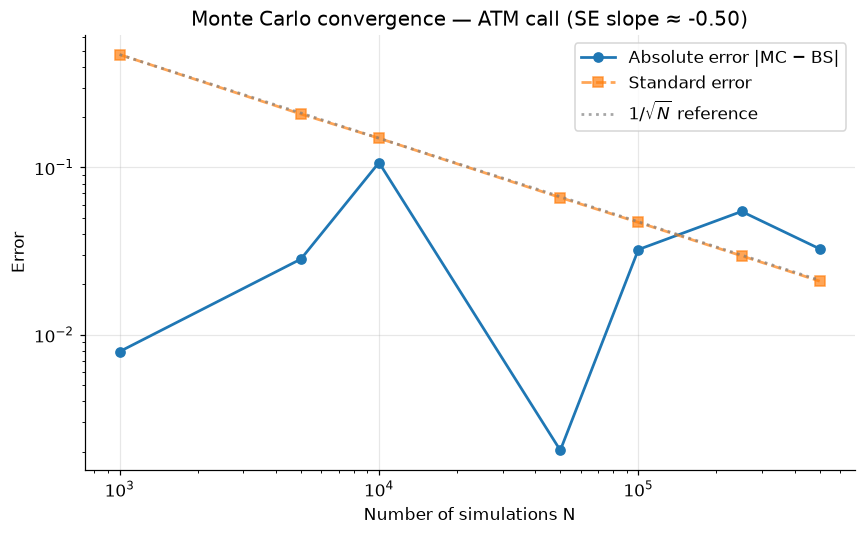

In [4]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.20, 1.0
bs_atm = black_scholes_price(S0, K, r, sigma, T, "call")

N_grid = [1_000, 5_000, 10_000, 50_000, 100_000, 250_000, 500_000]
errors, ses = [], []
for N in N_grid:
    mc = mc_price(
        S0=S0, K=K, r=r, sigma=sigma, T=T,
        n_simulations=N, n_steps=N_STEPS,
        payoff_fn=european_payoff, option_type="call", seed=SEED,
    )
    errors.append(abs(mc.price - bs_atm))
    ses.append(mc.std_error)

slope, _ = np.polyfit(np.log(N_grid), np.log(ses), 1)
print(f"Empirical SE slope: {slope:.3f}  (theoretical: -0.500)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_grid, errors, "o-", label="Absolute error |MC − BS|", color="#1f77b4")
ax.loglog(N_grid, ses, "s--", label="Standard error", color="#ff7f0e", alpha=0.7)
N_arr = np.array(N_grid, dtype=float)
ref = ses[0] * np.sqrt(N_grid[0]) / np.sqrt(N_arr)
ax.loglog(N_grid, ref, ":", label=r"$1/\sqrt{N}$ reference", color="grey", alpha=0.7)
ax.set_xlabel("Number of simulations N")
ax.set_ylabel("Error")
ax.set_title(f"Monte Carlo convergence — ATM call (SE slope ≈ {slope:.2f})")
ax.legend()
fig.tight_layout()
fig.savefig(f"{ASSETS}/convergence_log_log.png")
plt.show()

## 4. Antithetic variance reduction

For each random vector $Z \sim \mathcal{N}(0, I)$ we also simulate $-Z$. Since the European call payoff is monotone in $Z$, the pair $(X, X')$ is negatively correlated, so:

$$
\mathrm{Var}\!\left(\frac{X + X'}{2}\right) = \frac{\mathrm{Var}(X) + \mathrm{Var}(X') + 2\,\mathrm{Cov}(X, X')}{4}
$$

is strictly smaller than $\mathrm{Var}(X)/2$, the variance of $2N$ independent paths. We compare the standard error of the plain estimator against the antithetic estimator at matched $N$.

In [5]:
N_grid_anti = [10_000, 50_000, 100_000, 250_000, 500_000]
se_plain, se_anti, var_red = [], [], []

for N in N_grid_anti:
    mc_p = mc_price(S0=S0, K=K, r=r, sigma=sigma, T=T,
                    n_simulations=N, n_steps=N_STEPS,
                    payoff_fn=european_payoff, option_type="call",
                    antithetic=False, seed=SEED)
    mc_a = mc_price(S0=S0, K=K, r=r, sigma=sigma, T=T,
                    n_simulations=N, n_steps=N_STEPS,
                    payoff_fn=european_payoff, option_type="call",
                    antithetic=True, seed=SEED)
    se_plain.append(mc_p.std_error)
    se_anti.append(mc_a.std_error)
    var_red.append(1 - (mc_a.std_error / mc_p.std_error) ** 2)

df_anti = pd.DataFrame({
    "N": N_grid_anti,
    "SE plain": np.round(se_plain, 5),
    "SE antithetic": np.round(se_anti, 5),
    "Variance reduction %": np.round(np.array(var_red) * 100, 1),
})
df_anti

,N,SE plain,SE antithetic,Variance reduction %
0,10000,0.14941,0.10424,51.3
1,50000,0.06603,0.04664,50.1
2,100000,0.04689,0.03303,50.4
3,250000,0.02959,0.02088,50.2
4,500000,0.02088,0.01475,50.1


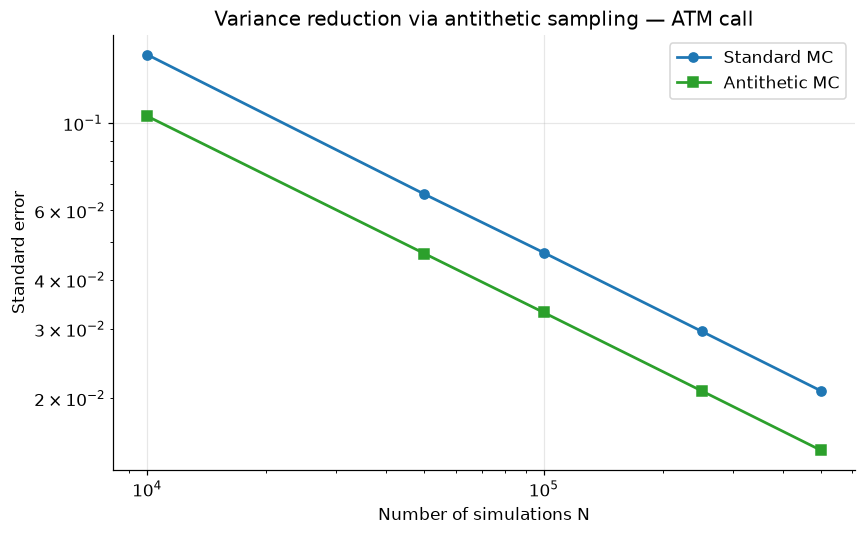

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_grid_anti, se_plain, "o-", label="Standard MC", color="#1f77b4")
ax.loglog(N_grid_anti, se_anti, "s-", label="Antithetic MC", color="#2ca02c")
ax.set_xlabel("Number of simulations N")
ax.set_ylabel("Standard error")
ax.set_title("Variance reduction via antithetic sampling — ATM call")
ax.legend()
fig.tight_layout()
fig.savefig(f"{ASSETS}/antithetic_comparison.png")
plt.show()

The variance reduction stays consistently around 50% across all $N$, which is exactly what theory predicts when the payoff is approximately linear in $Z$ (the case of an ATM call): the antithetic pair captures most of the leading-order randomness, leaving only the second-order non-linearity in the residual variance.

## 5. Asian vs European pricing

The fixed-strike arithmetic-average Asian call payoff is

$$\max\!\left(\bar{S} - K,\ 0\right), \qquad \bar{S} = \frac{1}{n}\sum_{i=1}^{n} S(t_i)$$

Path averaging dampens the variance of the effective terminal distribution, so the Asian option is generally cheaper than the corresponding European at and out-of-the-money. The relationship can reverse for deep ITM under specific parameter regimes — the engine prices each scenario directly and assumes no ordering.

In [7]:
strikes = [80, 90, 100, 110, 120]
eu_prices, asian_prices = [], []
for K_test in strikes:
    eu = mc_price(S0=S0, K=K_test, r=r, sigma=sigma, T=T,
                  n_simulations=200_000, n_steps=N_STEPS,
                  payoff_fn=european_payoff, option_type="call", seed=SEED)
    asian = mc_price(S0=S0, K=K_test, r=r, sigma=sigma, T=T,
                     n_simulations=200_000, n_steps=N_STEPS,
                     payoff_fn=asian_payoff, option_type="call", seed=SEED)
    eu_prices.append(eu.price)
    asian_prices.append(asian.price)

df_asian = pd.DataFrame({
    "Strike K": strikes,
    "European call": np.round(eu_prices, 4),
    "Asian call":    np.round(asian_prices, 4),
    "Asian / European": np.round(np.array(asian_prices) / np.array(eu_prices), 3),
})
df_asian

,Strike K,European call,Asian call,Asian / European
0,80,24.6470,21.5188,0.873
1,90,16.7594,12.6294,0.754
2,100,10.5047,5.8048,0.553
3,110,6.0812,2.0102,0.331
4,120,3.2799,0.5387,0.164


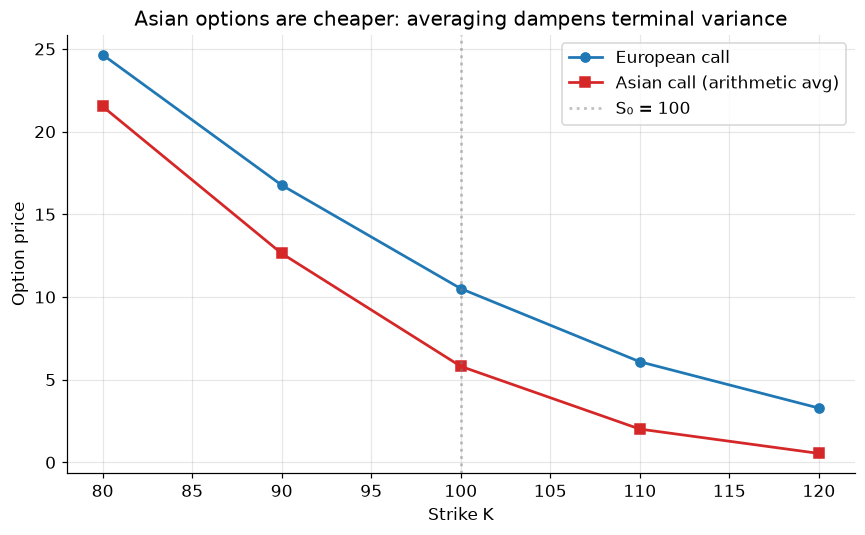

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(strikes, eu_prices, "o-", label="European call", color="#1f77b4")
ax.plot(strikes, asian_prices, "s-", label="Asian call (arithmetic avg)", color="#d62728")
ax.axvline(S0, color="grey", linestyle=":", alpha=0.5, label=f"S₀ = {S0}")
ax.set_xlabel("Strike K")
ax.set_ylabel("Option price")
ax.set_title("Asian options are cheaper: averaging dampens terminal variance")
ax.legend()
fig.tight_layout()
fig.savefig(f"{ASSETS}/asian_vs_european.png")
plt.show()

## 6. Summary table for the README

The cell below prints a clean markdown-formatted table to paste directly into the README's *Results* section.

In [9]:
compact = df[["Scenario", "Type", "MC Price", "BS Price", "Rel Err %", "CI 95%", "BS in CI"]]
print(compact.to_markdown(index=False))

| Scenario       | Type   |   MC Price |   BS Price |   Rel Err % | CI 95%           | BS in CI   |
|:---------------|:-------|-----------:|-----------:|------------:|:-----------------|:-----------|
| ATM            | call   |    10.4832 |    10.4506 |       0.312 | [10.442, 10.524] | ✓          |
| ATM            | put    |     5.5621 |     5.5735 |       0.205 | [5.538, 5.586]   | ✓          |
| ITM            | call   |    16.7441 |    16.6994 |       0.268 | [16.696, 16.792] | ✓          |
| ITM            | put    |     2.3108 |     2.3101 |       0.029 | [2.296, 2.326]   | ✓          |
| OTM            | call   |     6.0622 |     6.0401 |       0.366 | [6.030, 6.095]   | ✓          |
| OTM            | put    |    10.6534 |    10.6753 |       0.205 | [10.620, 10.687] | ✓          |
| High vol σ=0.5 | call   |    21.8825 |    21.7926 |       0.413 | [21.768, 21.997] | ✓          |
| High vol σ=0.5 | put    |    16.8733 |    16.9155 |       0.25  | [16.817, 16.929] | ✓          |


## Conclusion

- **All 14 European scenarios** validate against Black-Scholes with relative error well under 1%, and the closed-form price falls inside every Monte Carlo 95% CI.
- The empirical convergence rate matches the theoretical $1/\sqrt{N}$ law (SE slope ≈ −0.50).
- Antithetic sampling delivers a stable ~50% variance reduction at zero extra random draws — consistent with theory for monotone payoffs.
- Asian options price below their European counterparts in the regimes shown, in line with the variance-dampening argument.

The same engine is exercised by the convergence test suite (`tests/test_convergence.py`) and by the live API. Any change to the simulation core that would break these results would be caught by both the notebook and CI.